TF-IDF stands “Term Frequency — Inverse Document Frequency”.
This is a technique to quantify words in a set of documents. We generally compute a score for each word to signify its importance in the document and corpus. This method is a widely used technique in Information Retrieval and Text Mining.



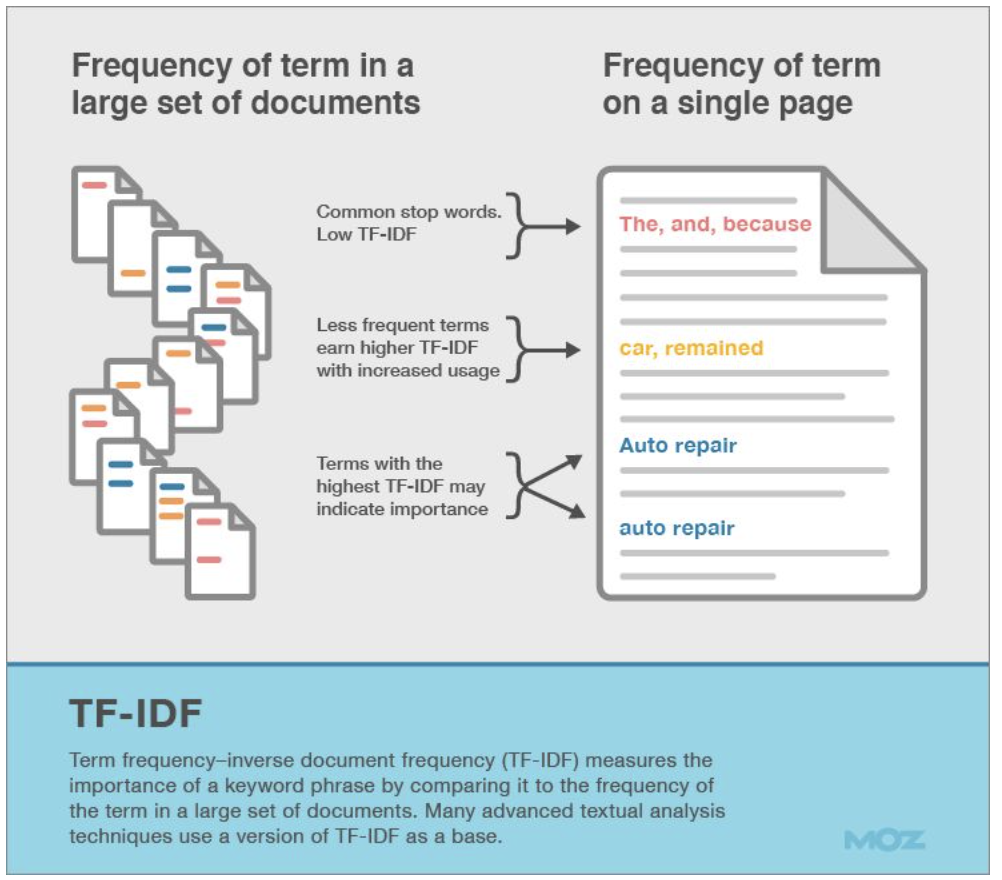



Documentation:https://en.wikipedia.org/wiki/Tf%E2%80%93idf

#### What is Term Frequency (tf)
tf is the number of times a term appears in a particular document. So it’s specific to a document. A few of the ways to calculate tf is given below:-

tf(t) = No. of times term ‘t’ occurs in a document

### Inverse Document Frequency (idf)
Idf is a measure of how common or rare a term is across the entire corpus of documents. So the point to note is that it’s common to all the documents. If the word is common and appears in many documents, the idf value (normalized) will approach 0 or else approach 1 if it’s rare. A few of the ways we can calculate idf value for a term is given below


#### Term Frequency-Inverse Document Frequency (tf-idf)
tf-idf value of a term in a document is the product of its tf and idf. The higher is the value, the more relevant the term is in that document.

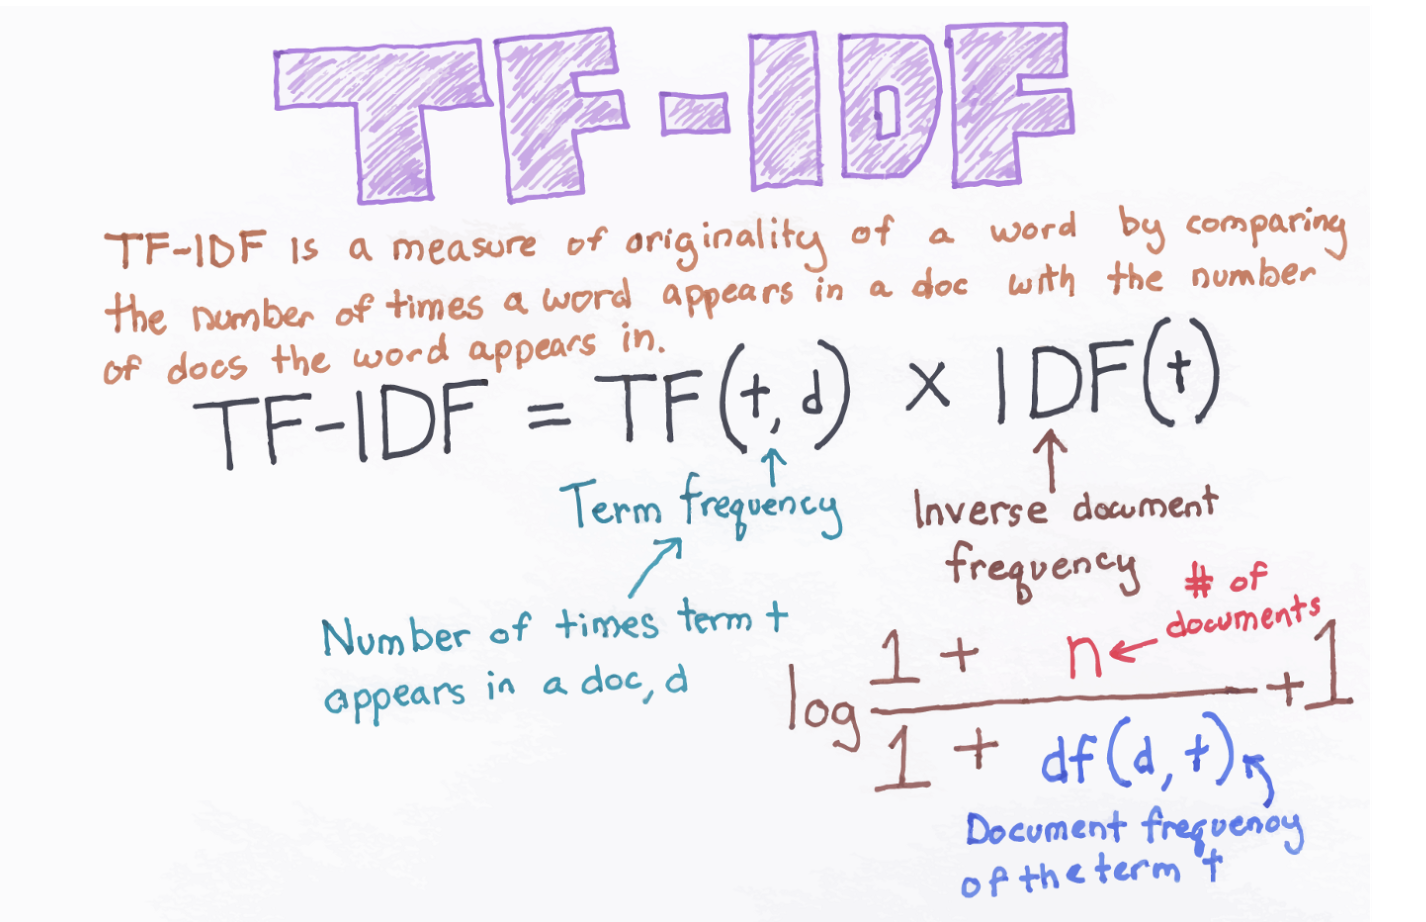

##### Step 1: Import the library


In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer

###### Step 2: Set up the document corpus

In [2]:
d1="petrol cars are cheaper than diesel cars"

d2="diesel is cheaper than petrol"

In [3]:
doc_corpus=[d1,d2]

In [4]:
print(doc_corpus)

['petrol cars are cheaper than diesel cars', 'diesel is cheaper than petrol']


###### Step 3: Initialize TfidfVectorizer and print the feature names

In [5]:
vec=TfidfVectorizer(stop_words='english')

In [6]:
matrix=vec.fit_transform(doc_corpus)

In [7]:
print("Feature Names n",vec.get_feature_names_out())

Feature Names n ['cars' 'cheaper' 'diesel' 'petrol']


In [8]:
matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (2, 4)>

###### Step 4: Generate a sparse matrix with tf-idf values

In [9]:
print("Sparse Matrix n",matrix.shape,"n",matrix.toarray())

Sparse Matrix n (2, 4) n [[0.85135433 0.30287281 0.30287281 0.30287281]
 [0.         0.57735027 0.57735027 0.57735027]]


##### Validate tf-idf values in the sparse matrix

To start with, the term frequency(tf) for each term in the documents is given in the above table.

Calculate idf values for each term.

As mentioned before , idf value of a term is common across all documents. Here we will consider the case when smooth_idf = True (default behaviour). So idf(t) is given by



###### idf(t) = log e [ (1+n) / ( 1 + df(t) ) ] + 1



###### Calculate tf-idf of the terms in each document d1 and d2.

###### For d1

tf-idf(“cars”) = tf(“cars”) x idf (“cars”) = 2 x 1.405465083 => 2.810930165

tf-idf(“cheaper”) = tf(“cheaper”) x idf (“cheaper”) = 1 x 1 => 1

tf-idf(“diesel”) = tf(“diesel”) x idf (“diesel”) = 1×1 => 1

tf-idf(“petrol”) = tf(“petrol”) x idf (“petrol”) = 1×1 => 1



###### For d2

tf-idf(“cars”) = tf(“cars”) x idf (“cars”) = 0 x 1.405465083 => 0

tf-idf(“cheaper”) = tf(“cheaper”) x idf (“cheaper”) = 1 x 1 => 1

tf-idf(“diesel”) = tf(“diesel”) x idf (“diesel”) = 1×1 => 1

tf-idf(“petrol”) = tf(“petrol”) x idf (“petrol”) = 1×1 => 1

So we have the sparse matrix with shape 2 x 3

[

[2.810930165                           1                     1                    1]

[0                                                1                     1                     1]

]

### Normalize tf-idf values

###### Conclusion from tf-idf values

Below were the tf values of both documents d1 and d2

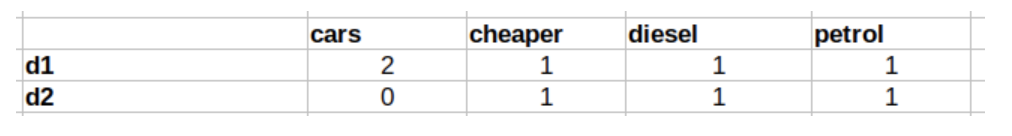




(i) In the first document d1, the term “cars” is the most relevant term as it has the highest tf-idf value (0.851354321)

(ii) In the second document d2, most of the terms have the same tf-idf value and have equal relevance.

#### Comparison between CountVectorizer vs TFIDF

##### Train Document Set:
d1: The sky is blue.

d2: The sun is bright.


##### Test Document Set:
d3: The sun in the sky is bright.

d4: We can see the shining sun, the bright sun.


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
import pandas as pd
# set of documents
train = ['The sky is blue.','The sun is bright.']
test = ['The sun in the sky is bright', 'We can see the shining sun, the bright sun.']
# instantiate the vectorizer object
countvectorizer = CountVectorizer(analyzer= 'word', stop_words='english')
tfidfvectorizer = TfidfVectorizer(analyzer='word',stop_words= 'english')
# convert th documents into a matrix
count_wm = countvectorizer.fit_transform(train)
tfidf_wm = tfidfvectorizer.fit_transform(train)
#retrieve the terms found in the corpora
# if we take same parameters on both Classes(CountVectorizer and TfidfVectorizer) , it will give same output of get_feature_names() methods)
#count_tokens = tfidfvectorizer.get_feature_names() # no difference
count_tokens = countvectorizer.get_feature_names_out()
tfidf_tokens = tfidfvectorizer.get_feature_names_out()
print("count_tokens:",count_tokens)
print("tfidf_tokens:",tfidf_tokens)



count_tokens: ['blue' 'bright' 'sky' 'sun']
tfidf_tokens: ['blue' 'bright' 'sky' 'sun']


In [12]:
df_countvect = pd.DataFrame(data = count_wm.toarray(),index = ['Doc1','Doc2'],columns = count_tokens)
df_tfidfvect = pd.DataFrame(data = tfidf_wm.toarray(),index = ['Doc1','Doc2'],columns = tfidf_tokens)
print("Count Vectorizer\n")
print(df_countvect)
print("\nTD-IDF Vectorizer\n")
print(df_tfidfvect)

Count Vectorizer

      blue  bright  sky  sun
Doc1     1       0    1    0
Doc2     0       1    0    1

TD-IDF Vectorizer

          blue    bright       sky       sun
Doc1  0.707107  0.000000  0.707107  0.000000
Doc2  0.000000  0.707107  0.000000  0.707107


Here , we can see clearly that Count Vectorizer give number of frequency with respect to index of vocabulary where as tf-idf consider overall documents of weight of words